## Load data

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

pd.set_option('display.max_rows', 80)

In [ ]:
train_df = pd.read_parquet("/content/drive/MyDrive/wb_wildhack_2026/train_solo_track.parquet")
test_df = pd.read_parquet("/content/drive/MyDrive/wb_wildhack_2026/test_solo_track.parquet")

## EDA

In [ ]:
train_df.head()

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,471,2025-07-28 00:00:00,13,23,45,85645,491354,487,88655
1,471,2025-07-28 00:30:00,14,18,1,80049,494754,489,223929
2,471,2025-07-28 01:00:00,8,8,38,82616,490659,487,168519
3,471,2025-07-28 01:30:00,10,2,7,80506,489967,494,111380
4,471,2025-07-28 02:00:00,7,5,13,85992,479743,494,246046


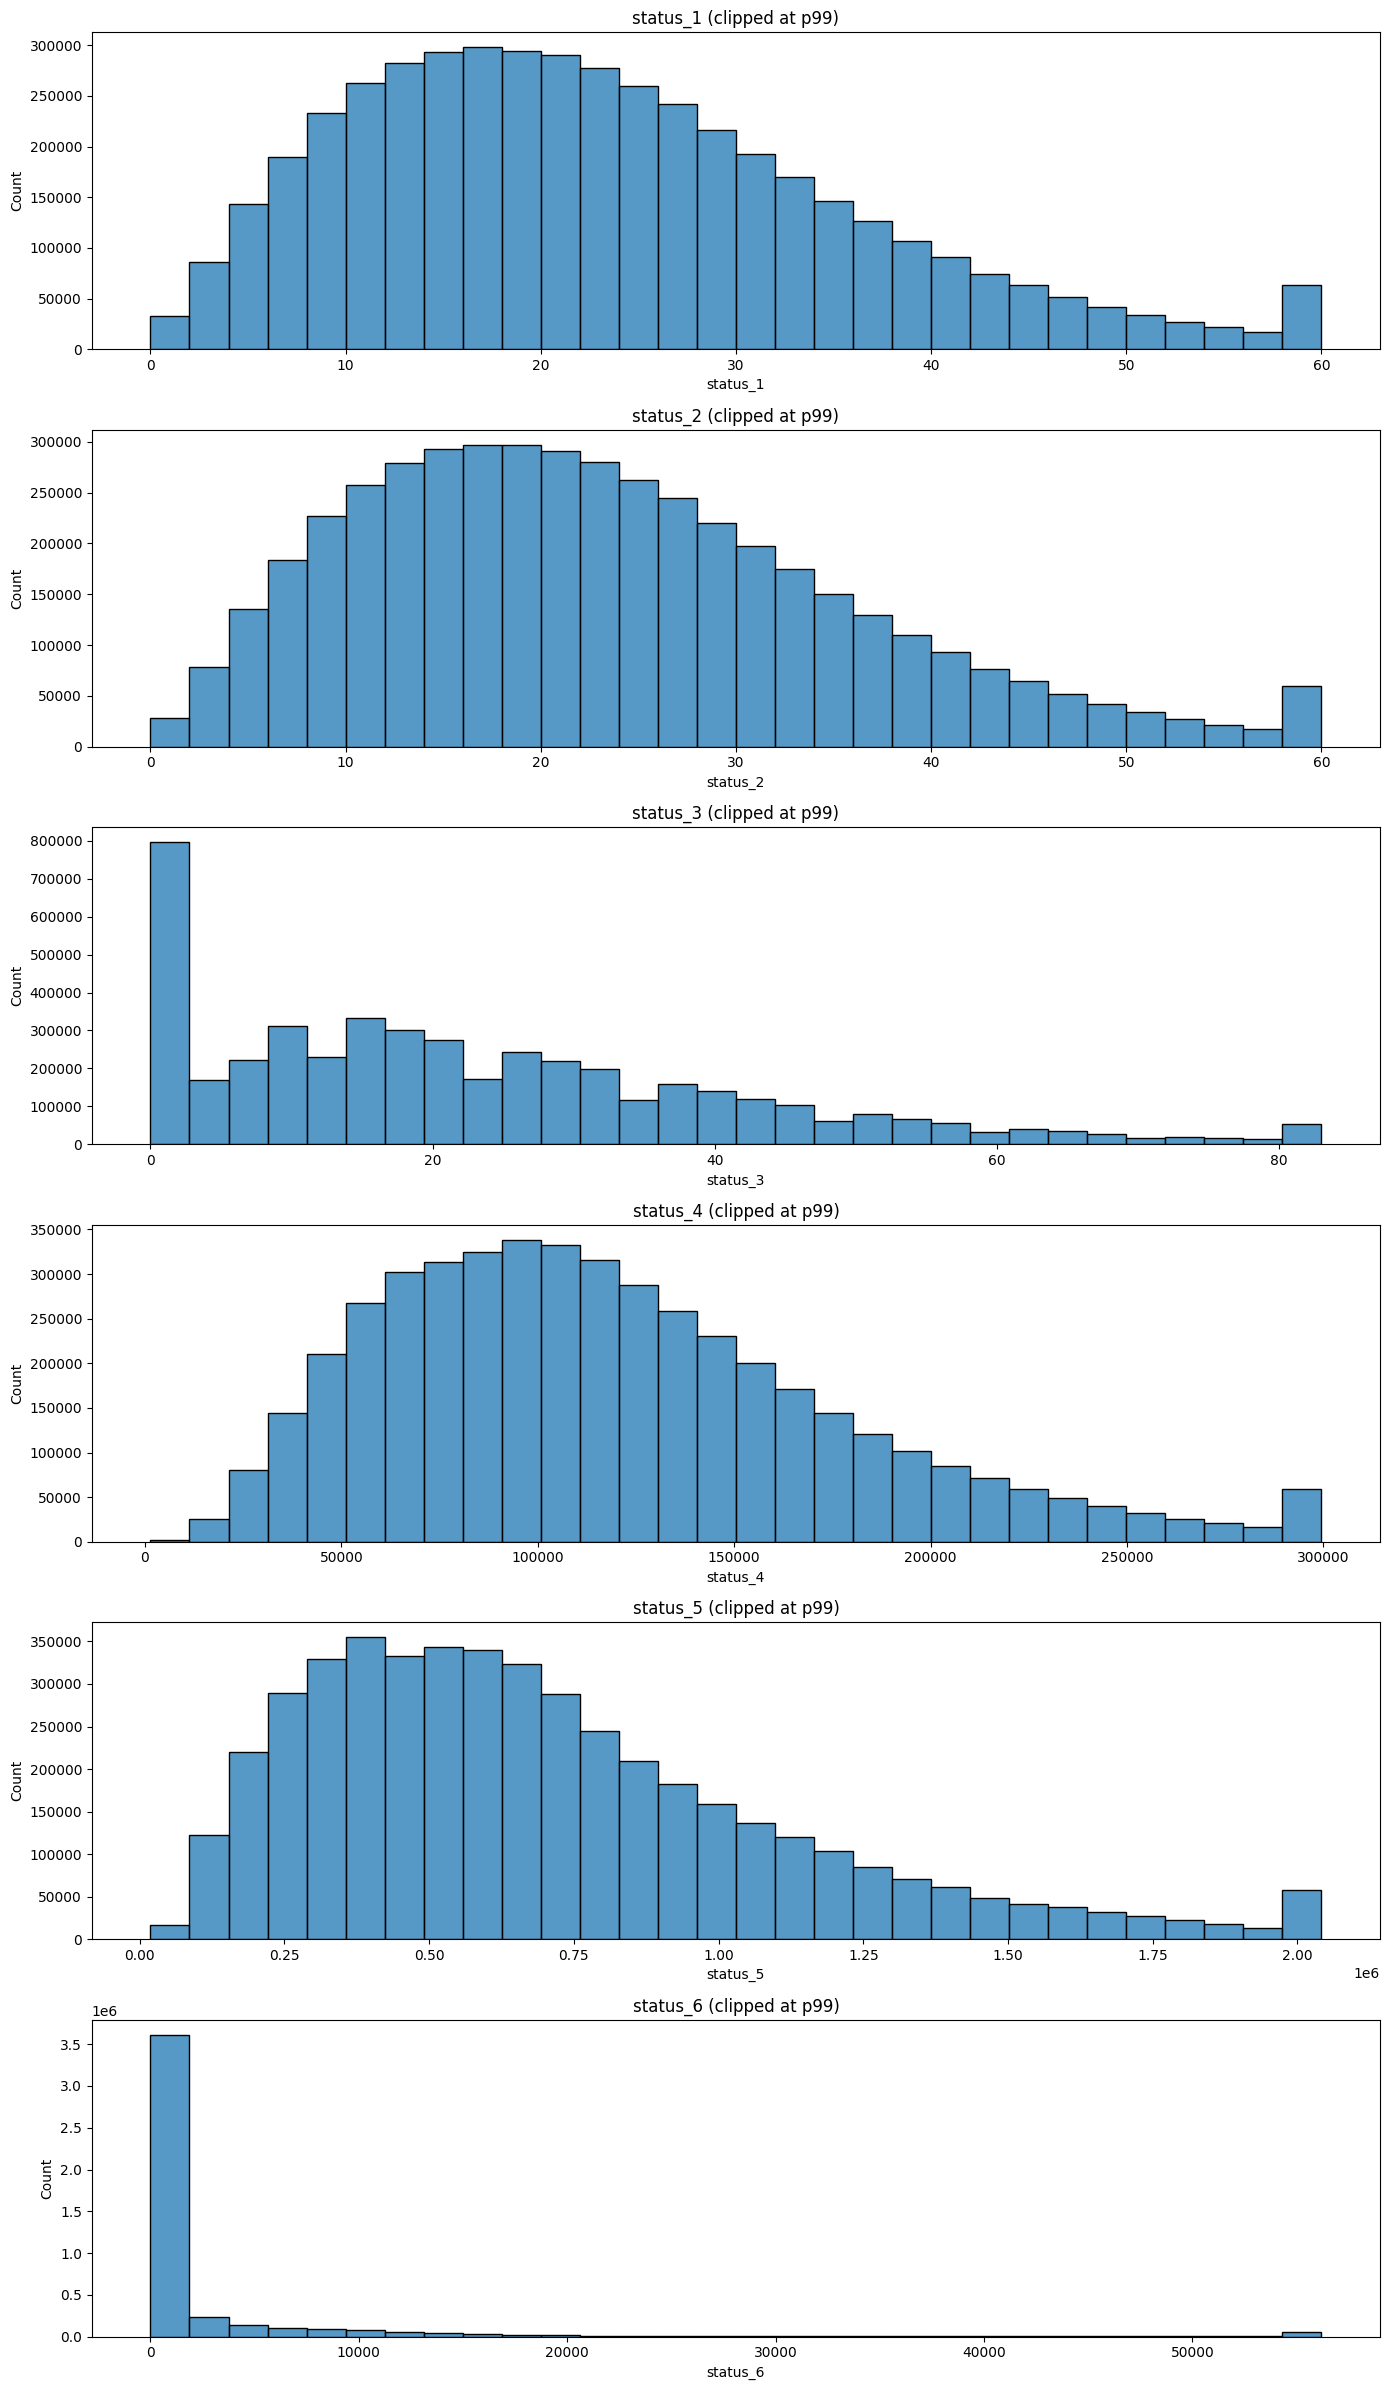

In [ ]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])

fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df["target_1h"].clip(upper=train_df["target_1h"].quantile(0.99)), bins=25, kde=False)
plt.title(f"target_1h (clipped at p99)")
plt.show()


In [ ]:
agg_func_math = {
    'timestamp': ['median', 'min', 'max', "count"]
}


# test_groups = test_df.groupby("route_id").agg(agg_func_math)
# train_groups = train_df.groupby("route_id").agg(agg_func_math)

In [ ]:
test_df

,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
3,3,471,2025-11-01 12:30:00
4,4,471,2025-11-01 13:00:00
...,...,...,...
7995,7995,422,2025-11-01 12:30:00
7996,7996,422,2025-11-01 13:00:00
7997,7997,422,2025-11-01 13:30:00
7998,7998,422,2025-11-01 14:00:00


In [ ]:
route_id = 471
timestamp_ = train_df[train_df["route_id" ]== route_id]["timestamp"].iloc[:48]
target_ = train_df[train_df["route_id"] == route_id]["target_1h"].iloc[:48]

plt.plot(timestamp_, target_)

## Feature generation

In [ ]:
import pandas as pd
import numpy as np

def create_features(train_df_, test_df_):
    train_df_['is_test'] = 0
    test_df_['is_test'] = 1
    df = pd.concat([train_df_, test_df_], axis=0)

    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek

    # 7 шагов = 3.5 часа. 48 = 1 сутки. 336 = 1 неделя.
    lags = [8, 9, 12, 24, 48, 48*2, 336, 336*2]

    # Колонки, которые будем сдвигать
    cols_to_shift = ['target_1h', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']


    grouped = df.groupby('route_id', sort="timestamp")

    shifted_dfs = []

    for lag in lags:
        shifted = grouped[cols_to_shift].shift(lag)
        new_columns_name = [f'{col}_lag_{lag}' for col in cols_to_shift]
        df[new_columns_name] = shifted

    df['rolling_mean_3h_target'] = df.groupby('route_id')['target_1h'].transform(
    lambda x: x.shift(8).rolling(window=6, min_periods=1).mean()
    )
    df['rolling_mean_6h_target'] = df.groupby('route_id')['target_1h'].transform(
    lambda x: x.shift(8).rolling(window=12, min_periods=1).mean()
    )
    df['rolling_mean_12h_target'] = df.groupby('route_id')['target_1h'].transform(
    lambda x: x.shift(8).rolling(window=24, min_periods=1).mean()
    )
    df['rolling_mean_24h_target'] = df.groupby('route_id')['target_1h'].transform(
    lambda x: x.shift(8).rolling(window=48, min_periods=1).mean()
    )
    df['rolling_mean_48h_target'] = df.groupby('route_id')['target_1h'].transform(
    lambda x: x.shift(8).rolling(window=48, min_periods=1).mean()
    )

    df['target_diff_day'] = df['target_1h_lag_48'] - df['target_1h_lag_96']
    df['trend_short_long'] = df['rolling_mean_6h_target'] / (df['rolling_mean_48h_target'] + 1e-6)
    status_cols = [f'status_{i}_lag_8' for i in range(1, 7)]
    df['total_status_load'] = df[status_cols].sum(axis=1)

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    df['route_hour_mean'] = df.groupby(['route_id', 'hour'])['target_1h'].transform('mean')
    df['route_day_mean'] = df.groupby(['route_id', 'dayofweek'])['target_1h'].transform('mean')

    df['ewm_target_24h'] = df.groupby('route_id')['target_1h'].transform(
    lambda x: x.shift(8).ewm(span=48).mean()
    )

    df['diff_yesterday_mean'] = df['target_1h_lag_48'] - df['route_hour_mean']
    df['short_term_bias'] = df['rolling_mean_6h_target'] - df['route_hour_mean']

    status_cols_8 = [f'status_{i}_lag_8' for i in range(1, 7)]
    status_cols_48 = [f'status_{i}_lag_48' for i in range(1, 7)]

    # Общая активность статусов 4 часа назад и сутки назад
    df['status_sum_lag_8'] = df[status_cols_8].sum(axis=1)
    df['status_sum_lag_48'] = df[status_cols_48].sum(axis=1)
    # Изменение общей активности (растет нагрузка на склад или падает?)
    df['status_load_velocity'] = df['status_sum_lag_8'] - df['status_sum_lag_48']

    df['days_to_weekend'] = (5 - df['dayofweek']) % 7

    # Время суток как категория (утро, день, вечер, ночь)
    df['time_block'] = (df['hour'] // 6).astype(int)

    df['target_std_12h'] = df.groupby('route_id')['target_1h'].transform(
        lambda x: x.shift(8).rolling(window=24).std()
    )

    train_df_ = df[df['is_test'] == 0]
    train_df_ = train_df_.drop(["id", "is_test"], axis=1)
    test_df_ = df[df['is_test'] == 1]
    test_df_ = test_df_.drop(["is_test"], axis=1)


    return train_df_, test_df_

train_df = train_df.sort_values(['route_id', 'timestamp'])
train_df, test_df = create_features(train_df, test_df)


gc.collect()

26

In [ ]:
train_df = train_df.dropna()
train_df = train_df.drop([ "status_1", "status_2", "status_3", "status_4", "status_5", "status_6"], axis=1)
test_df = test_df.drop(["target_1h", "status_1", "status_2", "status_3", "status_4", "status_5", "status_6"], axis=1)

In [ ]:
drop_features = [
    "status_3_lag_24",
    "status_3_lag_12",
    "status_4_lag_8",
    "status_6_lag_8",
    "status_1_lag_24",
    "status_4_lag_9",
    "status_3_lag_8",
    "status_4_lag_96",
    "status_5_lag_9",
    "status_1_lag_672",
    "status_6_lag_48",
    "status_3_lag_336",
    "status_3_lag_672",
    "status_3_lag_48",
    "status_1_lag_48",
    "status_3_lag_96",
    "status_1_lag_336",
    "status_2_lag_48",
    "status_2_lag_672",
    "status_2_lag_96",
]


In [ ]:
train_df = train_df.drop(drop_features, axis=1)
test_df = test_df.drop(drop_features, axis=1)

In [ ]:
train_df.head()

,route_id,timestamp,target_1h,hour,dayofweek,target_1h_lag_8,status_1_lag_8,status_2_lag_8,status_5_lag_8,target_1h_lag_9,...,route_day_mean,ewm_target_24h,diff_yesterday_mean,short_term_bias,status_sum_lag_8,status_sum_lag_48,status_load_velocity,days_to_weekend,time_block,target_std_12h
2269372,0,2025-08-11 00:00:00,40743.0,0,0,40865.0,2.0,9.0,149965.0,38880.0,...,158683.657738,108674.115745,-109839.592784,-62903.592784,192166.0,203702.0,-11536.0,5,0,56902.814284
2269373,0,2025-08-11 00:30:00,155521.0,0,0,1985.0,6.0,9.0,155188.0,40865.0,...,158683.657738,104319.457960,-32079.592784,-70858.426117,195102.0,199519.0,-4417.0,5,0,59821.941517
2269374,0,2025-08-11 01:00:00,237615.0,1,0,49167.0,11.0,9.0,159165.0,1985.0,...,158683.657738,102068.337227,-23706.958763,-66589.792096,199776.0,201617.0,-1841.0,5,0,60039.497544
2269375,0,2025-08-11 01:30:00,230811.0,1,0,107609.0,4.0,14.0,160514.0,49167.0,...,158683.657738,102294.486728,-62586.958763,-64102.375430,204756.0,204092.0,664.0,5,0,59672.618293
2269376,0,2025-08-11 02:00:00,158720.0,2,0,97322.0,15.0,6.0,163528.0,107609.0,...,158683.657738,102091.528086,-3156.304124,-68773.554124,206001.0,202348.0,3653.0,5,0,56184.866093


In [ ]:
test_df.isna().sum()

,0
route_id,0
timestamp,0
id,0
hour,0
dayofweek,0
target_1h_lag_8,0
status_1_lag_8,0
status_2_lag_8,0
status_5_lag_8,0
target_1h_lag_9,0


In [ ]:
# corr  = train_df.corr(numeric_only=True)
# plt.figure(figsize=(12, 10))
# sns.heatmap(corr, annot=False, fmt=".2f", cmap="coolwarm", center=0)
# plt.title("Correlations on supervised train")
# plt.show()

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 0 to 7999
Data columns (total 64 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   route_id                 8000 non-null   int64         
 1   timestamp                8000 non-null   datetime64[ns]
 2   id                       8000 non-null   float64       
 3   hour                     8000 non-null   int32         
 4   dayofweek                8000 non-null   int32         
 5   target_1h_lag_8          8000 non-null   float64       
 6   status_1_lag_8           8000 non-null   float64       
 7   status_2_lag_8           8000 non-null   float64       
 8   status_5_lag_8           8000 non-null   float64       
 9   target_1h_lag_9          8000 non-null   float64       
 10  status_1_lag_9           8000 non-null   float64       
 11  status_2_lag_9           8000 non-null   float64       
 12  status_3_lag_9           8000 non-null 

In [ ]:
import numpy as np

#
unique_timestamps = np.sort(train_df['timestamp'].unique())
cutoff_time = unique_timestamps[-7 * 48] # 7 * 48

print(f"Всего дат: {len(unique_timestamps)}")
print(f"Время отсечения (начало валидации): {cutoff_time}")

train_data = train_df[train_df['timestamp'] < cutoff_time]
val_data = train_df[train_df['timestamp'] >= cutoff_time]

print(f"Размер Train: {train_data.shape[0]} строк")
print(f"Размер Val: {val_data.shape[0]} строк")



Всего дат: 3958
Время отсечения (начало валидации): 2025-10-25T11:00:00.000000000
Размер Train: 3622000 строк
Размер Val: 336000 строк


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3622000 entries, 2269372 to 2110943
Data columns (total 64 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   route_id                 int64         
 1   timestamp                datetime64[ns]
 2   target_1h                float64       
 3   hour                     int32         
 4   dayofweek                int32         
 5   target_1h_lag_8          float64       
 6   status_1_lag_8           float64       
 7   status_2_lag_8           float64       
 8   status_5_lag_8           float64       
 9   target_1h_lag_9          float64       
 10  status_1_lag_9           float64       
 11  status_2_lag_9           float64       
 12  status_3_lag_9           float64       
 13  status_6_lag_9           float64       
 14  target_1h_lag_12         float64       
 15  status_1_lag_12          float64       
 16  status_2_lag_12          float64       
 17  status_4_lag_12          f

In [ ]:
len(val_data)

336000

## Metrics

In [ ]:
class WapePlusRbias:

    """Calculates as WAPE + Relative Bias."""

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:

        """Рассчитывает значение метрики."""

        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()

        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)

        return wape + rbias


custom_metric = WapePlusRbias()

## Catboost Train

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor, Pool
drop_cols = ['timestamp', 'target_1h', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']
features = [col for col in train_df.columns if col not in drop_cols]


cat_features = ['route_id']

train_pool = Pool(
    data=train_data[features],
    label=train_data['target_1h'],
    cat_features=cat_features
)

val_pool = Pool(
    data=val_data[features],
    label=val_data['target_1h'],
    cat_features=cat_features
)

In [ ]:
import numpy as np

class WapeRbiasObjective(object):
    def calc_ders_range(self, approxes, targets, weights):
        c = 1000
        n = len(approxes)

        sum_err = 0.0
        for i in range(n):
            sum_err += (approxes[i] - targets[i])

        # Рассчитываем производные для компоненты Bias (одна на весь батч)
        # Используем Pseudo-Huber для гладкости
        bias_denom = np.sqrt(sum_err**2 + c**2)
        grad_bias = sum_err / bias_denom
        hess_bias = (c**2) / (bias_denom**3)

        result = []
        for i in range(n):
            err = approxes[i] - targets[i]

            # Компонента WAPE (локальная для каждой точки)
            wape_denom = np.sqrt(err**2 + c**2)
            grad_wape = err / wape_denom
            hess_wape = (c**2) / (wape_denom**3)

            # Итоговые значения: CatBoost ожидает (-градиент, -гессиан)
            # Складываем локальный вклад и глобальный вклад смещения
            der1 = -(grad_wape + grad_bias)
            der2 = -(hess_wape + hess_bias)

            result.append((der1, der2))

        return result

class WapeRbiasMetric(object):
    def get_final_error(self, error, weight):
        return error

    def is_max_optimal(self):
        return False

    def evaluate(self, approxes, target, weight):
        # approxes[0] — это массив предсказаний
        approx = approxes[0]

        sum_abs_err = 0.0
        sum_target = 0.0
        sum_approx = 0.0

        for i in range(len(target)):
            t = target[i]
            # Предсказания могут быть отрицательными, обрезаем для метрики
            a = approx[i] if approx[i] > 0 else 0.0

            sum_abs_err += abs(a - t)
            sum_target += t
            sum_approx += a

        if sum_target < 1e-9:
            return 0.0, 1.0

        wape = sum_abs_err / sum_target
        rbias = abs(sum_approx / sum_target - 1.0)

        return wape + rbias, 1.0

In [ ]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=10,
    loss_function="MAE",
    eval_metric=WapeRbiasMetric(),
    random_seed=42,
    task_type='GPU',
    # bagging_temperature=0.8,
    # random_strength=2,
    early_stopping_rounds=100
)

In [ ]:
model.fit(
    train_pool,
    eval_set=val_pool,
    verbose=100
)


preds = model.predict(val_pool)
final_metric = custom_metric.calculate(val_data['target_1h'].values, preds)

final_metric

Default metric period is 5 because MAE, PythonUserDefinedPerObject is/are not implemented for GPU


0:	learn: 0.5802168	test: 0.5950910	best: 0.5950910 (0)	total: 962ms	remaining: 32m 3s
100:	learn: 0.5802147	test: 0.5950888	best: 0.5950888 (100)	total: 35.7s	remaining: 11m 10s
200:	learn: 0.5802126	test: 0.5950866	best: 0.5950866 (200)	total: 1m 9s	remaining: 10m 25s
300:	learn: 0.5802104	test: 0.5950844	best: 0.5950844 (300)	total: 1m 44s	remaining: 9m 50s
400:	learn: 0.5802083	test: 0.5950822	best: 0.5950822 (400)	total: 2m 18s	remaining: 9m 14s


CatBoostError: catboost/python-package/catboost/helpers.cpp:58: Traceback (most recent call last):
  File "_catboost.pyx", line 1320, in _catboost._MetricIsMaxOptimal
  File "/tmp/ipykernel_6085/745717392.py", line 44, in is_max_optimal
    def is_max_optimal(self):
    
KeyboardInterrupt


In [ ]:
gc.collect()

5162

In [ ]:

feature_importance = model.get_feature_importance()


feature_names = features
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=90)
plt.title('CatBoost Feature Importance')
plt.show()

In [ ]:
importance_df["Feature"].to_list()

In [ ]:
new_preds = preds * (val_data['target_1h'].values.sum() / preds.sum())


In [ ]:
final_metric = custom_metric.calculate(val_data['target_1h'].values, new_preds)
final_metric

np.float64(1.9038197213496164)

In [ ]:
"""
np.float64(0.3742797366328)
np.float64(0.3483126344898562) test bias correcion

np.float64(0.3537943855682488)
np.float64(0.3459577663455962)

np.float64(0.3452185789170295)

np.float64(0.34496009641774683)

np.float64(0.3445656122356051)


np.float64(0.34158135602564754)

np.float64(0.3412998301725149)
"""

In [ ]:
bias_coef = (val_data['target_1h'].values.sum() / preds.sum())


In [ ]:
bias_coef

## LightGBM

In [ ]:
import lightgbm as lgb
import numpy as np

# 1. Подготовка данных
# Важно: переводим категории в специальный тип данных
cat_features = ['hour', 'dayofweek', 'time_block'] # route_id
# for col in cat_features:
#     df[col] = df[col].astype('category')

# Делим на X и y (используем твой RMSE подход)
X_train = train_data.drop(['target_1h', 'timestamp'], axis=1)
y_train = train_data['target_1h']

X_val = val_data.drop(['target_1h', 'timestamp'], axis=1)
y_val = val_data['target_1h']

train_dataset = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=cat_features,
)

val_dataset = lgb.Dataset(
    X_val,
    label=y_val,
    categorical_feature=cat_features,
    reference=train_dataset,
)




In [ ]:
params = {
    'boosting_type': 'dart',
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 128,
    'max_depth': -1,
    'max_bin': 255,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 50,
    'verbose': 100,
    'device': 'gpu',
    'gpu_use_dp': False,
    'n_jobs': -1
}

callbacks = [
    lgb.log_evaluation(period=50),
]

model_lgbm = lgb.train(
    params,
    train_dataset,
    num_boost_round=2000,
    valid_sets=[train_dataset, val_dataset],
    valid_names=['train', 'valid'],
    callbacks=callbacks,
)

[LightGBM] [Warning] Provided parameters constrain tree depth (max_depth=10) without explicitly setting 'num_leaves'. This can lead to underfitting. To resolve this warning, pass 'num_leaves' (<=1024) in params. Alternatively, pass (max_depth=-1) and just use 'num_leaves' to constrain model complexity.
[LightGBM] [Warning] Provided parameters constrain tree depth (max_depth=10) without explicitly setting 'num_leaves'. This can lead to underfitting. To resolve this warning, pass 'num_leaves' (<=1024) in params. Alternatively, pass (max_depth=-1) and just use 'num_leaves' to constrain model complexity.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 12458
[LightGBM] [Info] Number of data points in the train set: 3622000, number of used features: 62
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin

Exception ignored on calling ctypes callback function: <function _log_callback at 0x7f52fe9bd1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


Trained a tree with leaves = 128 and depth = 14


Exception ignored on calling ctypes callback function: <function _log_callback at 0x7f52fe9bd1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


Trained a tree with leaves = 128 and depth = 14


Exception ignored on calling ctypes callback function: <function _log_callback at 0x7f52fe9bd1c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


Trained a tree with leaves = 128 and depth = 15


In [ ]:
preds = model_lgbm.predict(X_val)
preds = np.maximum(preds, 0)

custom_metric.calculate(y_val.values, preds)

np.float64(0.34888641607516646)

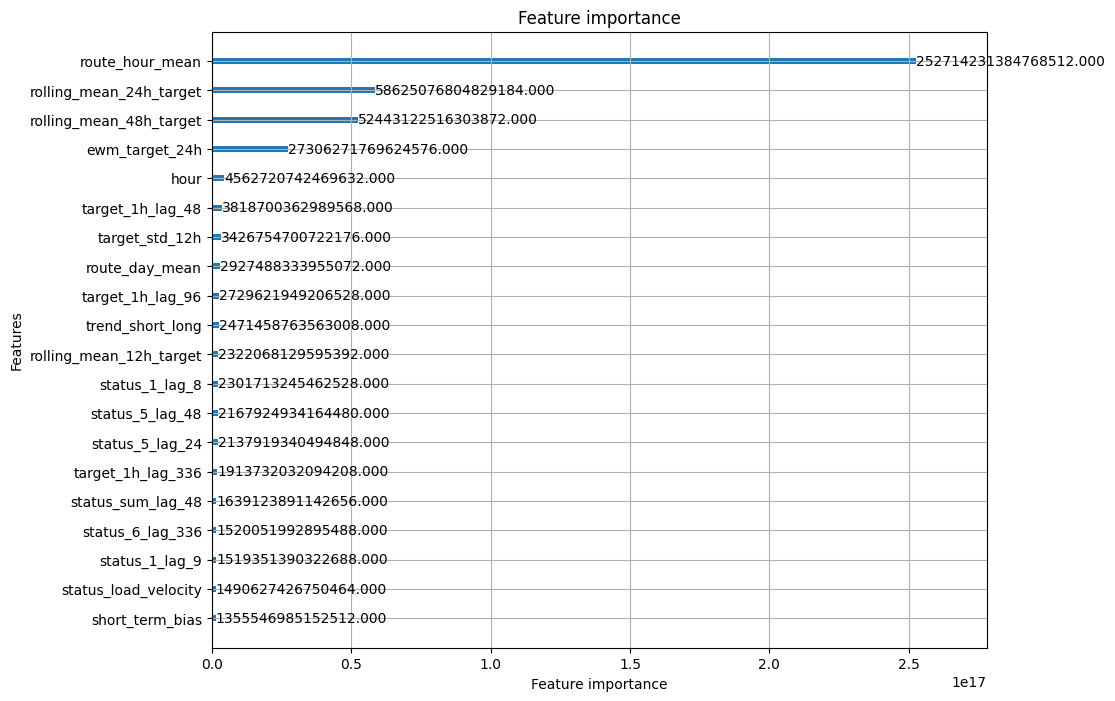

In [ ]:
lgb.plot_importance(model_lgbm, max_num_features=20, importance_type='gain', figsize=(10,8))
plt.show()

In [ ]:
gc.collect()

274

In [ ]:
X_train["route_id"].unique().size

1000

## Darts

In [ ]:
!pip install darts
!pip install pytorch-lightning

  Using cached pytorch_lightning-2.6.1-py3-none-any.whl.metadata (21 kB)
  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached lightning_utilities-0.15.3-py3-none-any.whl.metadata (5.5 kB)
Using cached pytorch_lightning-2.6.1-py3-none-any.whl (857 kB)
Using cached lightning_utilities-0.15.3-py3-none-any.whl (31 kB)
Using cached torchmetrics-1.9.0-py3-none-any.whl (983 kB)


In [ ]:
from darts import set_option
set_option("plotting.use_darts_style", True)

In [ ]:
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler



unique_timestamps = np.sort(train_df['timestamp'].unique())
cutoff_time = unique_timestamps[-7*48]

print(f"Всего дат: {len(unique_timestamps)}")
print(f"Время отсечения (начало валидации): {cutoff_time}")


train_data = train_df[train_df['timestamp'] < cutoff_time]
val_data = train_df[train_df['timestamp'] >= cutoff_time]

train_series = TimeSeries.from_group_dataframe(
    train_data,
    time_col='timestamp',
    group_cols='route_id',
    value_cols='target_1h',
    freq='30min'
)
val_series = TimeSeries.from_group_dataframe(
    val_data,
    time_col='timestamp',
    group_cols='route_id',
    value_cols='target_1h',
    freq='30min'
)


train_past_covariates = TimeSeries.from_group_dataframe(
    train_data,
    time_col='timestamp',
    group_cols='route_id',
    value_cols=['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6'],
    freq='30min'
)
val_past_covariates = TimeSeries.from_group_dataframe(
    val_data,
    time_col='timestamp',
    group_cols='route_id',
    value_cols=['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6'],
    freq='30min'
)

scaler_target = Scaler()
train_scaled = scaler_target.fit_transform(train_series)
val_scaled = scaler_target.transform(val_series)

scaler_past = Scaler()
train_past_scaled = scaler_past.fit_transform(train_past_covariates)
val_past_scaled = scaler_past.transform(val_past_covariates)


Всего дат: 4630
Время отсечения (начало валидации): 2025-10-25T11:00:00.000000000


In [ ]:
train_scaled = [s.astype(np.float32) for s in train_scaled]
val_scaled = [s.astype(np.float32) for s in val_scaled]

train_past_scaled = [s.astype(np.float32) for s in train_past_scaled]
val_past_scaled = [s.astype(np.float32) for s in val_past_scaled]

In [ ]:
import torch
import torch.nn as nn
from torchmetrics import Metric


class WapeBiasLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super(WapeBiasLoss, self).__init__()
        self.eps = eps

    def forward(self, pred, target):
        """
        pred, target: тензоры формы (Batch, Horizon, Components)
        """
        abs_diff = torch.abs(pred - target)
        sum_abs_diff = torch.sum(abs_diff)

        sum_pred = torch.sum(pred)
        sum_target = torch.sum(target)

        denominator = sum_target + self.eps

        wape = sum_abs_diff / denominator
        rbias = torch.abs(sum_pred / denominator - 1)

        return wape + rbias

class RMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self,yhat,y):
        return torch.sqrt(self.mse(yhat,y))

class WapeBiasMetric(Metric):
    def __init__(self):
        super().__init__()
        self.add_state("sum_abs_error", default=torch.tensor(0.0), dist_reduce_fx="sum")
        self.add_state("sum_bias_error", default=torch.tensor(0.0), dist_reduce_fx="sum")
        self.add_state("sum_actuals", default=torch.tensor(0.0), dist_reduce_fx="sum")

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        self.sum_abs_error += torch.sum(torch.abs(preds - target))
        self.sum_bias_error += torch.sum(preds - target)
        self.sum_actuals += torch.sum(target)

    def compute(self):
        # Финальный расчет: (Σ|y-p| + |Σ(p-y)|) / Σy
        wape = self.sum_abs_error / (self.sum_actuals + 1e-7)
        rbias = torch.abs(self.sum_bias_error / (self.sum_actuals + 1e-7))
        return wape + rbias

wape_bias_loss = WapeBiasLoss()

In [ ]:
import os
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [ ]:
from darts.models import TiDEModel
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torch.optim.lr_scheduler import StepLR
import torch

seed_everything(42)


early_stopper = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    mode='min',
)

model_tide = TiDEModel(
    input_chunk_length=48*3,
    output_chunk_length=8,

    # Архитектура
    num_encoder_layers=3,
    num_decoder_layers=3,
    hidden_size=256,
    decoder_output_dim=16,
    optimizer_kwargs={'lr': 1e-3},


    dropout=0.2,
    add_encoders={
        'cyclic': {'future': ['hour', 'dayofweek']},
        'position': {'past': ['relative'], 'future': ['relative']},
        'transformer': Scaler()
    },
    log_tensorboard=True,


    batch_size=2048,
    n_epochs=2,
    loss_fn=RMSELoss(),
    torch_metrics=WapeBiasMetric(),

    save_checkpoints=True,        # Включаем автосохранение
    work_dir="/content/drive/MyDrive/wb_wildhack_2026/models", # Папка, куда будут падать чекпоинты
    model_name="my_tide_run",     # Имя файла/папки
    force_reset=True,              # Перезаписывать старые файлы с таким же именем

    pl_trainer_kwargs={
        "accelerator": "cuda",
        "precision": "bf16-mixed",
        "devices": [0],
        "enable_checkpointing": True,
        "callbacks": [early_stopper],
        "log_every_n_steps": 1,
    }
)


print("Запуск TiDE на GPU...")
model_tide.fit(
    series=train_scaled,
    past_covariates=train_past_scaled,
    val_series=val_scaled,
    val_past_covariates=val_past_scaled
)

In [ ]:
model_tide.save("br_bro.pt")

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir /content/drive/MyDrive/wb_wildhack_2026/models/my_tide_run/logs

In [ ]:
from darts.models import TiDEModel
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint
from torch.optim.lr_scheduler import StepLR
import torch

seed_everything(42)

early_stopper = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    mode='min',
)



model_tide = TiDEModel(
    input_chunk_length=48*3,
    output_chunk_length=8,

    # Архитектура
    num_encoder_layers=3,
    num_decoder_layers=3,
    hidden_size=256,
    decoder_output_dim=16,
    optimizer_kwargs={'lr': 1e-3},


    dropout=0.2,
    add_encoders={
        'cyclic': {'future': ['hour', 'dayofweek']},
        'position': {'past': ['relative'], 'future': ['relative']},
        'transformer': Scaler()
    },
    log_tensorboard=True,


    batch_size=2048,
    n_epochs=6,
    loss_fn=RMSELoss(),
    torch_metrics=WapeBiasMetric(),

    save_checkpoints=True,
    work_dir="/content/drive/MyDrive/wb_wildhack_2026/models",
    model_name="my_tide_run",     # Имя файла/папки
    force_reset=True,              # Перезаписывать старые файлы с таким же именем

    pl_trainer_kwargs={
        "accelerator": "cuda",
        "precision": "bf16-mixed",
        "devices": [0],
        "enable_checkpointing": True,
        "callbacks": [early_stopper],
        "log_every_n_steps": 1,
    }
)

# model_tide.load_weights_from_checkpoint(file_name="/content/drive/MyDrive/wb_wildhack_2026/models/last.ckpt")

START_TRAIN = 6 * 48


print("Запуск TiDE на GPU...")
model_tide.fit(
    series=train_scaled[-START_TRAIN:],
    past_covariates=train_past_scaled[-START_TRAIN:],
    val_series=val_scaled,
    val_past_covariates=val_past_scaled
)

In [ ]:
from darts.models import TiDEModel

model_tide = TiDEModel.load("330.pt", weights_only=False,  map_location=torch.device('cpu'))

In [ ]:
from pytorch_lightning.utilities.model_summary import summarize

summarize(model_tide.model, max_depth=2)

   | Name                         | Type             | Params | Mode  | FLOPs
-----------------------------------------------------------------------------------
0  | criterion                    | RMSELoss         | 0      | train | 0    
1  | criterion.mse                | MSELoss          | 0      | train | 0    
2  | train_criterion              | MSELoss          | 0      | train | 0    
3  | val_criterion                | MSELoss          | 0      | train | 0    
4  | train_metrics                | MetricCollection | 0      | train | 0    
5  | train_metrics.WapeBiasMetric | WapeBiasMetric   | 0      | train | 0    
6  | val_metrics                  | MetricCollection | 0      | train | 0    
7  | val_metrics.WapeBiasMetric   | WapeBiasMetric   | 0      | train | 0    
8  | past_cov_projection          | _ResidualBlock   | 2.8 K  | train | 0    
9  | past_cov_projection.dense    | Sequential       | 2.8 K  | train | 0    
10 | past_cov_projection.skip     | Linear           | 28 

In [ ]:
model_tide.model_params

OrderedDict([('output_chunk_shift', 0),
             ('num_encoder_layers', 3),
             ('num_decoder_layers', 3),
             ('decoder_output_dim', 16),
             ('hidden_size', 256),
             ('temporal_width_past', 4),
             ('temporal_width_future', 4),
             ('temporal_hidden_size_past', None),
             ('temporal_hidden_size_future', None),
             ('temporal_decoder_hidden', 32),
             ('use_layer_norm', False),
             ('dropout', 0.2),
             ('use_static_covariates', True),
             ('input_chunk_length', 144),
             ('output_chunk_length', 8),
             ('optimizer_kwargs', {'lr': 0.001}),
             ('add_encoders',
              {'cyclic': {'future': ['hour', 'dayofweek']},
               'transformer': Scaler}),
             ('batch_size', 2048),
             ('n_epochs', 3),
             ('loss_fn',
              RMSELoss(
                (mse): MSELoss()
              )),
             ('torch_metric

In [ ]:
print(model_tide.model)

_TideModule(
  (criterion): RMSELoss(
    (mse): MSELoss()
  )
  (train_criterion): MSELoss()
  (val_criterion): MSELoss()
  (train_metrics): MetricCollection(
    (WapeBiasMetric): WapeBiasMetric(),
    prefix=train_
  )
  (val_metrics): MetricCollection(
    (WapeBiasMetric): WapeBiasMetric(),
    prefix=val_
  )
  (past_cov_projection): _ResidualBlock(
    (dense): Sequential(
      (0): Linear(in_features=6, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4, bias=True)
      (3): MonteCarloDropout(p=0.2, inplace=False)
    )
    (skip): Linear(in_features=6, out_features=4, bias=True)
  )
  (future_cov_projection): _ResidualBlock(
    (dense): Sequential(
      (0): Linear(in_features=4, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4, bias=True)
      (3): MonteCarloDropout(p=0.2, inplace=False)
    )
    (skip): Linear(in_features=4, out_features=4, bias=True)
  )
  (encoders): Sequent

In [ ]:
# best_model = TiDEModel.load_from_checkpoint(
#     model_name="my_tide_run",
#     work_dir="/content/drive/MyDrive/wb_wildhack_2026/models",
#     best=True,
#     weights_only=False
# )
# model_tide.load_weights_from_checkpoint(file_name="/content/drive/MyDrive/wb_wildhack_2026/models/best-tide-epoch=09-val_loss=0.1305.ckpt")


In [ ]:

gc.collect()

58533

In [ ]:
torch.cuda.empty_cache()

In [ ]:
import numpy as np

# Оценка на последних 8 шагах для трейна и валида


def evaluate_model(model, input_series, target_values, past_covs, scaler, description=""):

    preds_scaled = model.predict(n=8, series=input_series, past_covariates=past_covs)


    preds_orig = scaler.inverse_transform(preds_scaled)


    all_true = np.concatenate([s.values().flatten() for s in target_values])
    all_pred = np.concatenate([p.values().flatten() for p in preds_orig])

    all_pred = np.maximum(all_pred, 0)

    metric_val = custom_metric.calculate(all_true, all_pred)


    print(f"Итоговая метрика (WAPE+Bias): {metric_val:.5f}")
    print("-" * 40)
    return metric_val


train_input_scaled = [s[:-8] for s in train_scaled]
train_past_input_scaled = [c[:-8] for c in train_past_scaled]
train_true_orig = [s[-8:] for s in train_series]

print("Оценка на ТРЕНИРОВОЧНОМ наборе:")
train_score = evaluate_model(
    model_tide,
    train_input_scaled,
    train_true_orig,
    train_past_input_scaled,
    scaler_target,
    "TRAIN SCORE"
)


val_true_orig = [s[:8] for s in val_series]

print("Оценка на ВАЛИДАЦИОННОМ наборе:")
val_score = evaluate_model(
    model_tide,
    train_scaled,
    val_true_orig,
    train_past_scaled,
    scaler_target,
    "VALIDATION SCORE"
)

gap = (val_score - train_score) / train_score * 100
print(f"Разрыв (Overfitting gap): {gap:.2f}%")

🔍 Оценка на ТРЕНИРОВОЧНОМ наборе (проверка на переобучение):


INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


📊 TRAIN SCORE
Итоговая метрика (WAPE+Bias): 0.32447
----------------------------------------
🚀 Оценка на ВАЛИДАЦИОННОМ наборе (реальное качество):


INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


📊 VALIDATION SCORE
Итоговая метрика (WAPE+Bias): 0.34256
----------------------------------------
Разрыв (Overfitting gap): 5.57%


In [ ]:
full_series = TimeSeries.from_group_dataframe(
    train_df,
    time_col='timestamp',
    group_cols='route_id',
    value_cols='target_1h',
    freq='30min'
)

full_past_covs = TimeSeries.from_group_dataframe(
    train_df,
    time_col='timestamp',
    group_cols='route_id',
    value_cols=['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6'],
    freq='30min'
)


full_series_scaled = scaler_target.transform(full_series)
full_past_covs_scaled = scaler_past.transform(full_past_covs)

full_series_scaled = [s.astype(np.float32) for s in full_series_scaled]
full_past_covs_scaled = [s.astype(np.float32) for s in full_past_covs_scaled]


In [ ]:
# Настройка честной валидации
VAL_PERIOD = 7 * 48  # 336 шагов (неделя)


backtest_results = model_tide.historical_forecasts(
    series=full_series_scaled,         # Полный ряд (Train + Val)
    past_covariates=full_past_covs_scaled,  # Полные статусы (Train + Val)
    start=len(train_scaled[0]),        # Начинаем ровно с границы валидации
    forecast_horizon=8,                # Прогноз на 4 часа (как в Хакатоне)
    stride=8,                          # Сдвиг на 4 часа (берем новые точки из валида)
    retrain=False,
    last_points_only=False,
    overlap_end=False,
    verbose=True
)


INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Generating TimeSeries: 100%|██████████| 42000/42000 [00:10<00:00, 4049.66it/s]


In [ ]:
from functools import reduce

# Склеиваем временные ряды для каждого маршрута
print("Склеиваю временные ряды...")
all_combined_scaled = []
for i in range(len(backtest_results)):
    chunks = backtest_results[i]
    # Собираем все предсказанные отрезки в один длинный ряд для маршрута i
    res_scaled = reduce(lambda x, y: x.concatenate(y), chunks)
    all_combined_scaled.append(res_scaled)

# Пакетное обратное масштабирование (scaler_target понимает список из 1000 серий)
print("Возвращаю реальный масштаб...")
all_combined_orig = scaler_target.inverse_transform(all_combined_scaled)

# Фильтрация и сбор данных для метрики
all_preds_flat = []
all_true_flat = []

for i in range(len(all_combined_orig)):
    pred_series = all_combined_orig[i]

    # Синхронизируем прогноз с реальными данными из val_series
    actual_series = val_series[i].slice_intersect(pred_series)

    # Добавляем фильтр по часам (11:00 - 14:30)
    mask = (pred_series.time_index.hour >= 11) & (pred_series.time_index.hour <= 14)

    # Извлекаем значения только для целевого окна
    p_values = pred_series.values().flatten()[mask]
    a_values = actual_series.values().flatten()[mask]

    all_preds_flat.append(p_values)
    all_true_flat.append(a_values)


y_pred = np.maximum(np.concatenate(all_preds_flat), 0)
y_true = np.concatenate(all_true_flat)

print(f"\nРЕЗУЛЬТАТ (Окно 11:00-14:30):")
print(custom_metric.calculate(y_true, y_pred))

Склеиваю временные ряды...
Возвращаю реальный масштаб...

✅ ЧЕСТНЫЙ РЕЗУЛЬТАТ (Окно 11:00-14:30):
0.33633426781661535


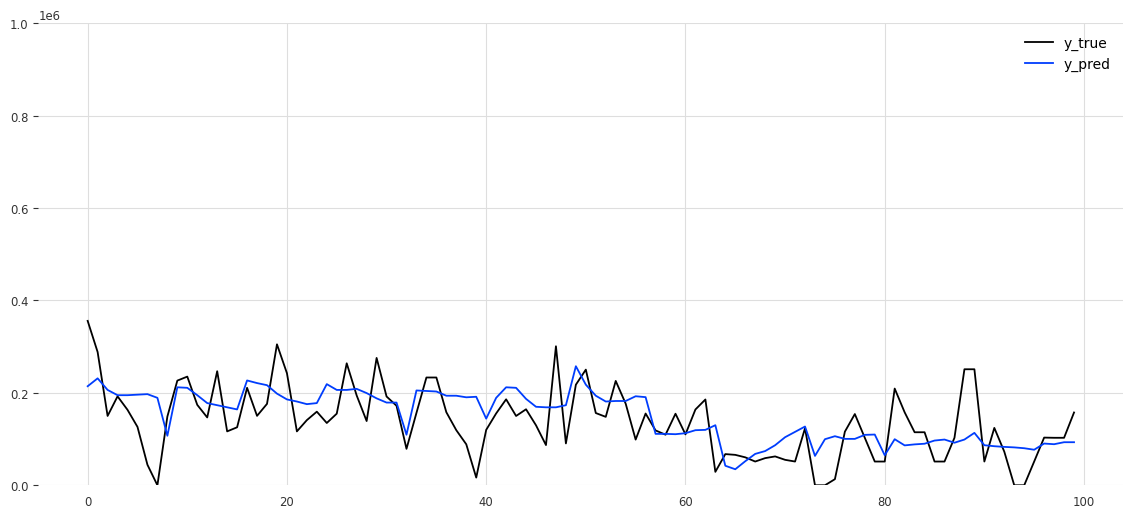

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="y_true")
plt.plot(y_pred[:100], label="y_pred")
ax = plt.gca()
# ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 1e6])
plt.legend()

In [ ]:
fix_coef = sum(y_true) / sum(y_pred)
print(custom_metric.calculate(y_true, y_pred * fix_coef))

0.32195139838684694


In [ ]:
fix_coef

np.float64(0.98567644605348)

In [ ]:
# 📊 VALIDATION SCORE
# Итоговая метрика (WAPE+Bias): 0.32912

## TiDE Submission


In [ ]:
test_df

,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
3,3,471,2025-11-01 12:30:00
4,4,471,2025-11-01 13:00:00
...,...,...,...
7995,7995,422,2025-11-01 12:30:00
7996,7996,422,2025-11-01 13:00:00
7997,7997,422,2025-11-01 13:30:00
7998,7998,422,2025-11-01 14:00:00


In [ ]:
import pandas as pd
import numpy as np


preds_scaled = model_tide.predict(
    n=8,
    series=full_series_scaled,
    past_covariates=full_past_covs_scaled
)

preds_orig = scaler_target.inverse_transform(preds_scaled)

my_preds_list = []

for i, series in enumerate(preds_orig):
    p_df = pd.DataFrame({
        'timestamp': series.time_index,
        'target_1h': series.values().flatten(),
        'route_id': i
    })
    my_preds_list.append(p_df)

my_preds_df = pd.concat(my_preds_list, ignore_index=True)




test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
my_preds_df['timestamp'] = pd.to_datetime(my_preds_df['timestamp'])


final_sub = test_df[['id', 'timestamp', 'route_id']].merge(
    my_preds_df,
    on=['timestamp', 'route_id'],
    how='left'
)


final_sub['target_1h'] = final_sub['target_1h'].clip(lower=0)

submission = pd.DataFrame({
        'id': test_df['id'],
        'y_pred': final_sub['target_1h']
    })


submission.to_csv('submission_tide_pro.csv', index=False)


print(f"Строк в файле: {len(final_sub)}")
print(submission.head())

In [ ]:
final_sub.info()

In [ ]:
submission

In [ ]:
test_df

,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
3,3,471,2025-11-01 12:30:00
4,4,471,2025-11-01 13:00:00
...,...,...,...
7995,7995,422,2025-11-01 12:30:00
7996,7996,422,2025-11-01 13:00:00
7997,7997,422,2025-11-01 13:30:00
7998,7998,422,2025-11-01 14:00:00


## Submission

In [ ]:
import gc
gc.collect()

12135

In [ ]:
test_df.head()

,route_id,timestamp,id,hour,dayofweek,target_1h_lag_8,status_1_lag_8,status_2_lag_8,status_5_lag_8,target_1h_lag_9,...,route_day_mean,ewm_target_24h,diff_yesterday_mean,short_term_bias,status_sum_lag_8,status_sum_lag_48,status_load_velocity,days_to_weekend,time_block,target_std_12h
0,471,2025-11-01 11:00:00,0.0,11,5,149161.0,10.0,12.0,675280.0,144158.0,...,135479.075851,162184.810230,-100283.098958,23359.067708,775067.0,744539.0,30528.0,0,1,94809.335497
1,471,2025-11-01 11:30:00,1.0,11,5,139669.0,19.0,17.0,675497.0,149161.0,...,135479.075851,161265.797568,-145172.098958,20035.234375,767909.0,746891.0,21018.0,0,1,94544.488473
2,471,2025-11-01 12:00:00,2.0,12,5,392495.0,13.0,18.0,666616.0,139669.0,...,135479.075851,170703.724198,-27134.302083,53077.031250,762727.0,749814.0,12913.0,0,2,105772.391280
3,471,2025-11-01 12:30:00,3.0,12,5,407785.0,14.0,13.0,659623.0,392495.0,...,135479.075851,180380.510965,127170.697917,67190.447917,760123.0,748766.0,11357.0,0,2,113718.686613
4,471,2025-11-01 13:00:00,4.0,13,5,105067.0,8.0,13.0,658081.0,407785.0,...,135479.075851,177306.490110,119725.130208,43313.046875,753186.0,753532.0,-346.0,0,2,110905.751140


In [ ]:
test_df.isna().sum()

,0
route_id,0
timestamp,0
id,0
hour,0
dayofweek,0
target_1h_lag_8,0
status_1_lag_8,0
status_2_lag_8,0
status_5_lag_8,0
target_1h_lag_9,0


In [ ]:
import pandas as pd
import numpy as np





def make_submission(model, test_df, features, filename='submission.csv', bias_multiplier=1.0):
    """
    Формирует файл решения для отправки на платформу.

    Параметры:
    - model: обученная модель (например, CatBoostRegressor)
    - test_df: тестовый датафрейм (с уже сгенерированными фичами и колонкой id)
    - features: список названий колонок, на которых училась модель
    - filename: имя итогового файла
    - bias_multiplier: коэффициент для корректировки Bias (по умолчанию 1.0 - без изменений)
    """

    X_test = test_df[features]

    preds = model.predict(X_test) * bias_coef

    preds = np.maximum(preds, 0)


    preds = preds * bias_multiplier

    submission = pd.DataFrame({
        'id': test_df['id'],
        'y_pred': preds
    })

    submission.to_csv(filename, index=False)

    print(f"Количество строк: {len(submission)}")
    print(f"Пример данных:\n{submission.head(3)}")

    return submission

In [ ]:
make_submission(model=model, test_df=test_df, features=features, filename='wildhack_sub_1.csv')

In [ ]:
# from darts.models import TiDEModel
# from pytorch_lightning.callbacks.early_stopping import EarlyStopping
# import torch

# # 2. НАСТРОЙКА МОДЕЛИ
# early_stopper = EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     min_delta=0.001,
#     mode='min',
# )

# model_tide = TiDEModel(
#     input_chunk_length=48*3,      # Смотрим на 48 часов назад
#     output_chunk_length=8,      # Предсказываем на 3.5 часа

#     # Архитектура
#     num_encoder_layers=2,       # Глубина кодировщика
#     num_decoder_layers=2,       # Глубина декодировщика
#     hidden_size=256,            # Ширина слоев (можно 512 для 1000 маршрутов)
#     decoder_output_dim=16,      # Размерность выхода декодера

#     # Специфичные фишки TiDE
#     use_reversible_instance_norm=True, # ОГРОМНЫЙ БУСТ: помогает при разном масштабе отгрузок
#     dropout=0.2,

#     # Обучение
#     batch_size=2048,
#     n_epochs=3,
#     optimizer_kwargs={'lr': 1e-3},
#     loss_fn=wape_bias_loss,

#     pl_trainer_kwargs={
#         "accelerator": "cuda",
#         # "precision": "bf16-mixed",
#         "devices": [0],
#         "callbacks": [early_stopper]
#     }
# )

# # 3. ОБУЧЕНИЕ
# print("Запуск TiDE на GPU...")
# model_tide.fit(
#     series=train_scaled,
#     past_covariates=train_past_scaled,
#     val_series=val_scaled,
#     val_past_covariates=val_past_scaled
# )


# INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
# INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
# INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
# INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

# Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s

# 🔍 Оценка на ТРЕНИРОВОЧНОМ наборе (проверка на переобучение):

# 📊 TRAIN SCORE
# Итоговая метрика (WAPE+Bias): 0.34634
# ----------------------------------------
# 🚀 Оценка на ВАЛИДАЦИОННОМ наборе (реальное качество):

# INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
# INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
# INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
# INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

# Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s

# /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

# 📊 VALIDATION SCORE
# Итоговая метрика (WAPE+Bias): 0.32912
# ----------------------------------------
# Разрыв (Overfitting gap): -4.97%



In [ ]:
# from darts.models import TiDEModel
# from pytorch_lightning.callbacks.early_stopping import EarlyStopping
# import torch

# seed_everything(42)

# # 2. НАСТРОЙКА МОДЕЛИ
# early_stopper = EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     min_delta=0.001,
#     mode='min',
# )

# model_tide = TiDEModel(
#     input_chunk_length=48*3,      # Смотрим на 48 часов назад
#     output_chunk_length=8,      # Предсказываем на 3.5 часа

#     # Архитектура
#     num_encoder_layers=3,       # Глубина кодировщика
#     num_decoder_layers=3,       # Глубина декодировщика
#     hidden_size=256,            # Ширина слоев (можно 512 для 1000 маршрутов)
#     decoder_output_dim=16,      # Размерность выхода декодера

#     # Специфичные фишки TiDE
#     # use_reversible_instance_norm=True, # ОГРОМНЫЙ БУСТ: помогает при разном масштабе отгрузок
#     dropout=0.2,

#     # Обучение
#     batch_size=2048,
#     n_epochs=3,
#     optimizer_kwargs={'lr': 1e-3},
#     loss_fn=RMSELoss(),

#     pl_trainer_kwargs={
#         "accelerator": "cuda",
#         # "precision": "bf16-mixed",
#         "devices": [0],
#         "callbacks": [early_stopper]
#     }
# )

# # 3. ОБУЧЕНИЕ
# print("Запуск TiDE на GPU...")
# model_tide.fit(
#     series=train_scaled,
#     past_covariates=train_past_scaled,
#     val_series=val_scaled,
#     val_past_covariates=val_past_scaled
# )




# INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
# INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
# INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
# INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
# INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

# Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s

# 🔍 Оценка на ТРЕНИРОВОЧНОМ наборе (проверка на переобучение):

# INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
# INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
# INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
# INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
# INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

# Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s

# 📊 TRAIN SCORE
# Итоговая метрика (WAPE+Bias): 0.32708
# ----------------------------------------
# 🚀 Оценка на ВАЛИДАЦИОННОМ наборе (реальное качество):

# /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

# 📊 VALIDATION SCORE
# Итоговая метрика (WAPE+Bias): 0.32721
# ----------------------------------------
# Разрыв (Overfitting gap): 0.04%

